# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

An area plot makes it easy to see the combined nutrient burden at a glance, so it is useful if the main question is whether the water sample is approaching or exceeding an overall eutrophication threshold. It also uses space efficiently and can make broad changes over time feel visually obvious.

The downside is that stacked areas make the upper series harder to read precisely because phosphate is measured from the top of nitrate rather than from a common baseline. That makes exact month-to-month comparison more difficult and can exaggerate or hide changes depending on where the lower series moves.

Two separate line charts are better when the goal is accurate comparison of patterns, slopes, and timing. If I wanted to improve the presentation, I would use a shared date axis, clear axis labels with the same units, direct labels instead of a legend when possible, and a reference line marking the eutrophic threshold. If I kept the area chart, I would use lighter fills, stronger outlines, and add annotations to emphasize the most important months.

In [8]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

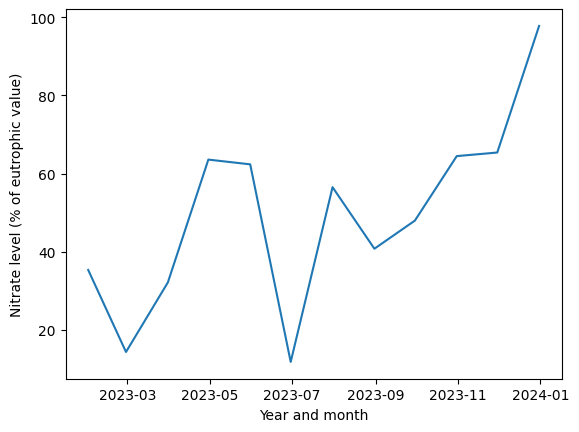

In [9]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

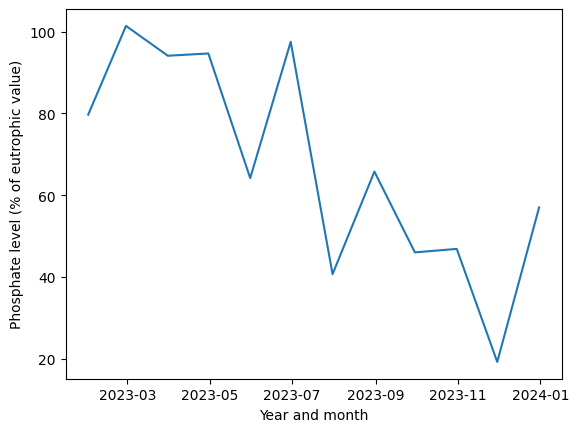

In [10]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

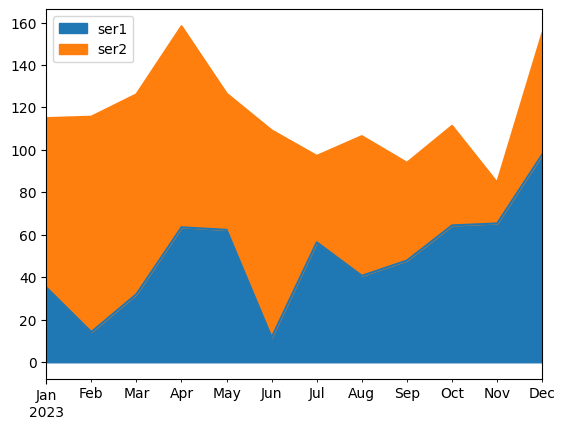

In [11]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

                       ROI
ROI               1.000000
Engagement_Score  0.354717
Clicks            0.188343
Impressions       0.166009
Conversion_Rate  -0.000249
Acquisition_Cost -0.001659


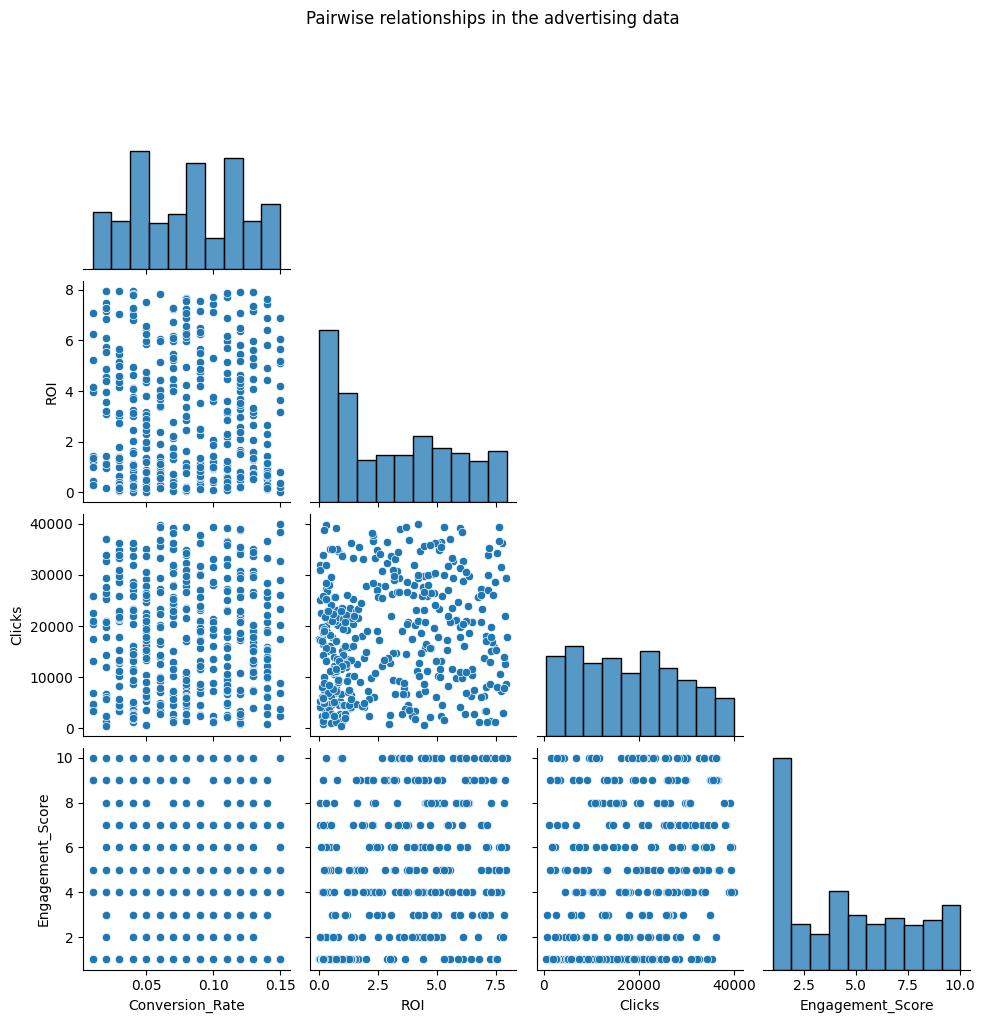

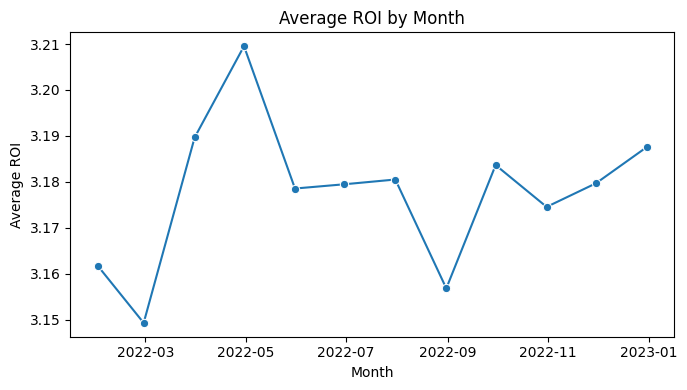

In [12]:
import matplotlib.pyplot as plt

ads_df = pd.read_csv("Social_Media_Advertising.csv", parse_dates = ["Date"])
ads_df["Acquisition_Cost"] = ads_df["Acquisition_Cost"].replace(r"[$,]", "", regex = True).astype(float)

analysis_columns = ["Conversion_Rate", "Acquisition_Cost", "ROI", "Clicks", "Impressions", "Engagement_Score"]
print(ads_df[analysis_columns].corr()[["ROI"]].sort_values("ROI", ascending = False))

pair_grid = sns.pairplot(
    ads_df[["Conversion_Rate", "ROI", "Clicks", "Engagement_Score"]].sample(400, random_state = 42),
    corner = True
)
pair_grid.fig.suptitle("Pairwise relationships in the advertising data", y = 1.02)

monthly_roi = ads_df.groupby(pd.Grouper(key = "Date", freq = "ME"))["ROI"].mean().reset_index()
plt.figure(figsize = (7, 4))
ax = sns.lineplot(data = monthly_roi, x = "Date", y = "ROI", marker = "o")
ax.set_title("Average ROI by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average ROI")
plt.tight_layout()

Using the advertising dataset, the strongest relationships with ROI appear to come from engagement and conversion behavior rather than from raw impressions alone. The pair plot suggests that clicks and impressions move together, which means those variables may be partly redundant for modeling. The monthly ROI line also shows meaningful variation over time, so any comparison across campaigns should control for seasonality or campaign timing rather than assuming the campaigns are directly comparable.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

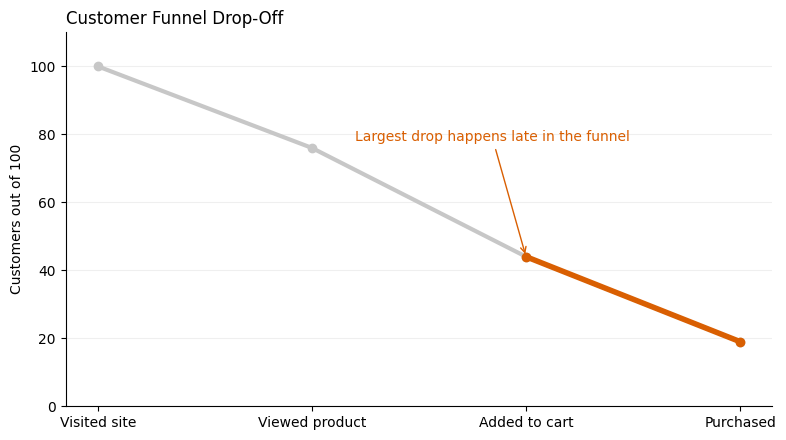

In [13]:
import matplotlib.pyplot as plt

highlighted = pd.DataFrame({
    "stage": ["Visited site", "Viewed product", "Added to cart", "Purchased"],
    "customers": [100, 76, 44, 19]
})

fig, ax = plt.subplots(figsize = (8, 4.5))
ax.plot(highlighted["stage"], highlighted["customers"], color = "#c7c7c7", linewidth = 3, marker = "o")
ax.plot(highlighted["stage"].iloc[-2:], highlighted["customers"].iloc[-2:], color = "#d95f02", linewidth = 4, marker = "o")
ax.set_title("Customer Funnel Drop-Off", loc = "left")
ax.set_ylabel("Customers out of 100")
ax.set_ylim(0, 110)
ax.grid(axis = "y", alpha = 0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.annotate(
    "Largest drop happens late in the funnel",
    xy = (2, 44),
    xytext = (1.2, 78),
    arrowprops = dict(arrowstyle = "->", color = "#d95f02"),
    color = "#d95f02"
)
plt.tight_layout()